# Beamline Simulation Tutorial: Scripting with `shadow4`
## Part 3 — A Refocusing Mirror with Measured Figure Errors

*Bay Area Light Source Joint User Meeting, 2026*

**Contact:**
- Wei "Francis" He — francisho@lbl.gov
- Dr. Antoine Islegen-Wojdyla — awojdyla@lbl.gov

**Acknowledgements:**

Beamline parameters are taken from the ALS-U COSMIC-U (7.0.1) optical design. The height map is a metrology measurement of COSMIC-U's M103 mirror.

---

## This Notebook

Part 2's monochromator, followed by an elliptical mirror that refocuses the beam horizontally onto the same screen. The mirror is not ideal: it carries the height errors measured on a real optic. We take the export apart as before, look at how the measured map is put on the mirror, and finish with the trade-off every exit slit makes: resolving power against flux.

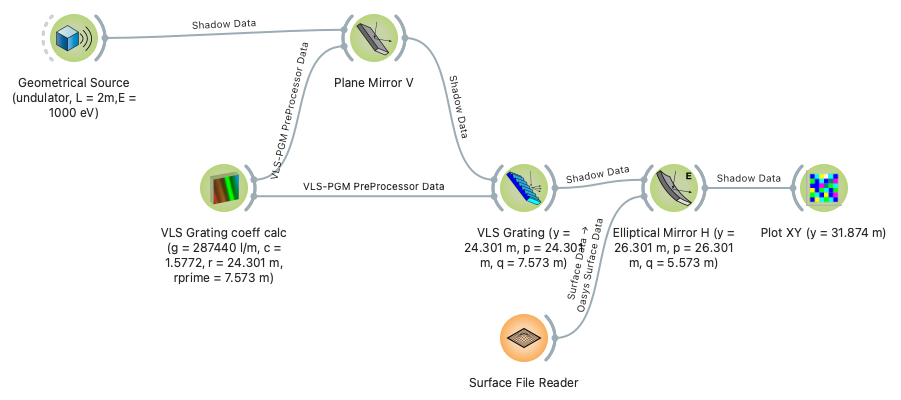

Source → plane mirror (V) → VLS grating, 287 440 lines/m (V) → elliptical cylinder at 26.301 m with measured figure errors (H) → screen at 31.874 m.

### Contents

- **0. Setup** — packages and imports.
- **1. The script from Oasys** — the export, and what is new with a third optic.
- **2. Retrace and plot** — which column is which after three optics, and the `spot()` helper.
- **3. Component breakdown** — every block rebuilt and checked ray for ray against the paste; then the height map and how it is put on the mirror.
- **4. Ideal vs. measured, and the exit slit** — the same beamline with and without the errors, and a slit-width scan.

### Resources

- shadow4 source code and examples: [github.com/oasys-kit/shadow4](https://github.com/oasys-kit/shadow4)
- Oasys: [github.com/oasys-kit](https://github.com/oasys-kit)

## 0. Setup

```bash
pip install shadow4 srxraylib h5py
```

Same packages as Part 1, plus `h5py` to open the height-map file. Tested with Python 3.13 and shadow4 0.1.92.

The height map ships with this notebook in `data/`; run the notebook from the folder it lives in.

In [1]:
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt

for pkg in ["shadow4", "syned", "srxraylib", "h5py", "numpy", "matplotlib"]:
    print(f"{pkg:11s} {version(pkg)}")

shadow4     0.1.88
syned       1.0.57
srxraylib   1.0.68
h5py        3.16.0
numpy       2.5.2
matplotlib  3.11.1


## 1. The Script from Oasys

Output of the *Python Script* widget attached to the *Plot XY* in the canvas above, with **one line changed**: `surface_data_file`. The export records the absolute path of the height map on the computer that wrote it; here it points at the copy in `data/`, next to this notebook.

> __Note:__ On the _Plot XY_ widget, select 'retraced' for 'Position of the image'.

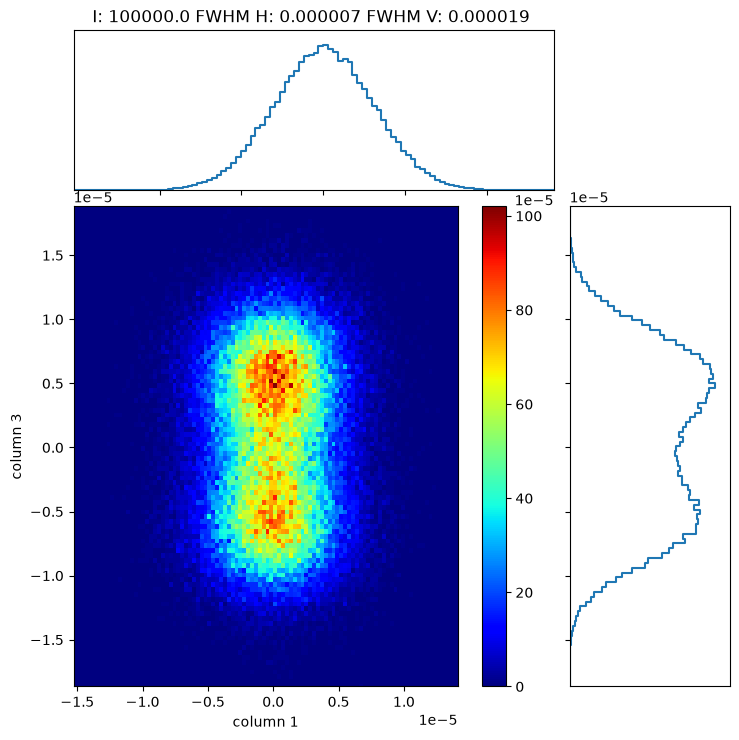

(<Figure size 800x800 with 4 Axes>,
 <Axes: xlabel='column 1', ylabel='column 3'>,
 <Axes: title={'center': 'I: 100000.0 FWHM H: 0.000007 FWHM V: 0.000019 '}>,
 <Axes: >)

In [2]:
import numpy as np

def run_beamline():
    footprint = None
    import numpy as np
    from dabax.dabax_xraylib import DabaxXraylib
    from shadow4.beamline.s4_beamline import S4Beamline
    
    beamline = S4Beamline()
    
    #
    #
    #
    from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
    light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
    light_source.set_spatial_type_gaussian(sigma_h=1.65e-05,sigma_v=1.84e-05)
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=1.86e-05,sigdiz=1.83e-05)
    light_source.set_energy_distribution_singleline(1000, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    beam = light_source.get_beam()
    
    beamline.set_light_source(light_source)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155)
       
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
    optical_element = S4PlaneMirror(name='Plane Mirror V', boundary_shape=boundary_shape,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
    beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.09, y_top=0.09)
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating
    optical_element = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
        boundary_shape=None, f_ruling=1, order=-1,
        ruling=287440.0, ruling_coeff_linear=142771.836, 
        ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
        ruling_coeff_quartic=0.0,
        )
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)
    movements = None
    from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
    beamline_element = S4PlaneGratingElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.1258, y_top=0.126)
            
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror
    optical_element = S4EllipsoidMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)', boundary_shape=boundary_shape,
        surface_calculation=0, # 0=Internal calculation, 1=External 
        min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
        p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156, # for surface_calculation=0
        is_cylinder=1, cylinder_direction=0, convexity=1,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    ideal_mirror = optical_element
    boundary_shape = None
            
    from shadow4.beamline.optical_elements.mirrors.s4_numerical_mesh_mirror import S4NumericalMeshMirror
    optical_element = S4NumericalMeshMirror(name='Numerical Mesh Mirror', boundary_shape=boundary_shape,
        xx=None, yy=None, zz=None, surface_data_file='data/shadow4_COSMIC-U_M3_AXO_DLTP_Resid_4thOrderRemoved_IntResidHeight.h5',
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='', # for f_refl=0,2,3,4
        refraction_index=1, # for f_refl=1
        coating_material='', coating_density=1, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None, # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    numerical_mesh_mirror = optical_element
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.1258, y_top=0.126)
    
    from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirror
    optical_element = S4AdditionalNumericalMeshMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)', ideal_mirror=ideal_mirror, numerical_mesh_mirror=numerical_mesh_mirror)
        
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=-5.573, q=5.573, angle_radial=1.548979711, angle_azimuthal=1.570796327, angle_radial_out=1.548979711)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirrorElement
    beamline_element = S4AdditionalNumericalMeshMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    return beam, footprint

#
# main 
#
from srxraylib.plot.gol import plot, plot_image, plot_image_with_histograms, plot_show

# WARNING: NO incremental result allowed!!"
beam, footprint = run_beamline()
beam.retrace(0.000000)

ticket = beam.histo2(1, 3, nbins_h=100, nbins_v=100, xrange=[np.float64(-1.82085631615595e-05), np.float64(1.68020325871322e-05)], yrange=[np.float64(-2.112760046229389e-05), np.float64(2.076283483649384e-05)], nolost=1, ref=23)

title = "I: %.1f " % ticket['intensity']
if ticket['fwhm_h'] is not None: title += "FWHM H: %f " % ticket['fwhm_h']
if ticket['fwhm_v'] is not None: title += "FWHM V: %f " % ticket['fwhm_v']

plot_image_with_histograms(ticket['histogram'], ticket['bin_h_center'], ticket['bin_v_center'],
    title=title, xtitle="column 1", ytitle="column 3",
    cmap='jet', add_colorbar=True, figsize=(8, 8), histo_path_flag=1, show=1)

### What is new compared with Part 2

The source, the plane mirror and the grating are Part 2's blocks, line for line. The **third block** is the refocusing mirror, and it builds three objects instead of one:

```python
optical_element = S4EllipsoidMirror(...)                  # the ideal ellipse, as in Part 1
ideal_mirror = optical_element

optical_element = S4NumericalMeshMirror(..., surface_data_file=...)   # the measured height map
numerical_mesh_mirror = optical_element

optical_element = S4AdditionalNumericalMeshMirror(ideal_mirror=ideal_mirror,
                                                  numerical_mesh_mirror=numerical_mesh_mirror)
```

The height map is **added to** the ideal ellipse, not used in its place: the file holds deviations of a few nanometres, not the shape of the mirror. The combined optic takes its aperture from the ideal mirror, −125.8 to +126.0 mm along its length. The `Rectangle` built just before `S4AdditionalNumericalMeshMirror` is never passed to it — the same pattern as the grating in Part 2.

| | Elliptical mirror |
|---|---|
| `p` [m] | −5.573 |
| `q` [m] | 5.573 |
| `angle_radial` [rad] | 1.548979711 (1.25° grazing) |
| `angle_azimuthal` [rad] | π/2 — deflects horizontally |

**The negative `p`.** The grating's `q` = 7.573 m carries the rays all the way to the screen plane at 31.874 m. The mirror's `p` = −5.573 m then steps back 5.573 m from there, which puts the mirror at 26.301 m, and its `q` = 5.573 m brings the beam forward to the screen again.

## 2. Retrace and Plot

`# main` is Part 1's: trace, `retrace(0)`, `histo2` on columns 1 and 3. What changes with three optics is which lab direction each column is.

### 2.1 Which column is which

After each optic, **column 3 lies in that optic's deflection plane and column 1 across it** (Part 1, 3.3). With three optics, apply the rule three times:

| After | Azimuth | Deflects | Column 1 | Column 3 |
|---|---|---|---|---|
| plane mirror | 0 | vertically | lab horizontal | lab vertical |
| grating | π | vertically | lab horizontal | lab vertical — dispersed and focused by the grating |
| elliptical mirror | π/2 | horizontally | **lab vertical** | **lab horizontal** — focused by the mirror |

So at the screen, column 1 is the grating's dispersive direction and column 3 is the direction the elliptical mirror focuses. Both come to a focus here.

**Checking it by tracing.** A ray keeps its row in `beam.rays` from the source to the screen. Draw the source again with the export's seed, and colour every ray on the screen by where it started.

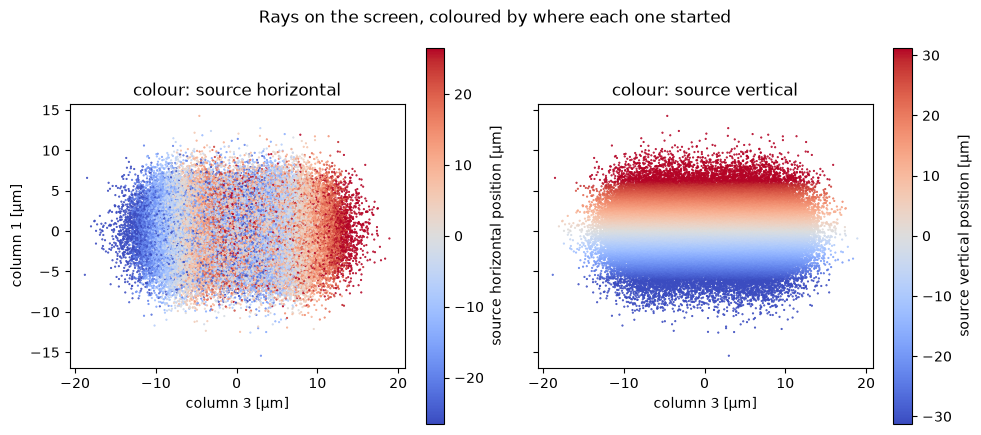

correlation with the source's    horizontal (x)   vertical (z)
   column 1                         +0.004          +1.000
   column 3                         +0.426          +0.003


In [3]:
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical

# The export's source again: same settings, same seed, so row i is where ray i started.
src = SourceGeometrical(nrays=100000, seed=12)
src.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
src.set_depth_distribution_off()
src.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
src.set_energy_distribution_singleline(1000, unit='eV')
start = src.get_beam().rays

good = beam.rays[:, 9] > 0
col1_um, col3_um = beam.rays[good, 0] * 1e6, beam.rays[good, 2] * 1e6

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharex=True, sharey=True)
for ax, (src_col, name) in zip(axes, [(0, "horizontal"), (2, "vertical")]):
    start_um = start[good, src_col] * 1e6
    lim_um = 2 * start_um.std()
    sc = ax.scatter(col3_um, col1_um, c=start_um, s=0.3, cmap="coolwarm",
                    vmin=-lim_um, vmax=lim_um, rasterized=True)
    fig.colorbar(sc, ax=ax, label=f"source {name} position [µm]")
    ax.set_title(f"colour: source {name}")
    ax.set_xlabel("column 3 [µm]")
    ax.set_aspect("equal")
axes[0].set_ylabel("column 1 [µm]")
fig.suptitle("Rays on the screen, coloured by where each one started")
plt.tight_layout()
plt.show()

corr = lambda a, b: np.corrcoef(a, b)[0, 1]
r = {(col, s): corr(beam.rays[good, col - 1], start[good, s - 1]) for col in (1, 3) for s in (1, 3)}
print("correlation with the source's    horizontal (x)   vertical (z)")
for col in (1, 3):
    print(f"   column {col}                         {r[(col, 1)]:+.3f}          {r[(col, 3)]:+.3f}")

assert abs(r[(1, 3)]) > 0.99                              # column 1 is the source's vertical, ray for ray
assert abs(r[(1, 1)]) < 0.02 and abs(r[(3, 3)]) < 0.02    # neither column mixes in the other direction
assert abs(r[(3, 1)]) > 10 * abs(r[(3, 3)])               # column 3 follows the source's horizontal

Column 1 is the source's vertical position, ray for ray: the grating images it sharply. Column 3 follows the source's horizontal position only loosely — something between the source and the screen is scattering the rays horizontally. That is the mirror's figure error, and Section 3 puts it there on purpose.

### 2.2 A reusable `spot()` helper

Part 1's helper, copied unchanged except for the labels, which come from the table in 2.1. They happen to be Part 1's; the physics behind them is not — here both columns are focused.

In [4]:
from srxraylib.plot.gol import plot_image_with_histograms

LAB = {1: "lab vertical", 3: "lab horizontal"}   # this beamline only — see 2.1

def weighted_rms(values, weights):
    mean = np.average(values, weights=weights)
    return np.sqrt(np.average((values - mean) ** 2, weights=weights))

def spot(beam, title="", nbins=201, plot=True):
    # image of the beam in columns 1 and 3, plus its widths; all lengths in metres
    t = beam.histo2(1, 3, nbins_h=nbins, nbins_v=nbins, nolost=1, ref=23)   # no ranges: fit the rays
    rays = beam.rays[beam.rays[:, 9] > 0]
    intensity = beam.get_column(23, nolost=1)      # each ray's weight
    sizes = {"fwhm_1_m": t["fwhm_h"], "fwhm_3_m": t["fwhm_v"],
             "rms_1_m": weighted_rms(rays[:, 0], intensity),
             "rms_3_m": weighted_rms(rays[:, 2], intensity),
             "intensity": t["intensity"]}

    if plot:
        head = (f"{title}\ncolumn 1 ({LAB[1]}): {sizes['fwhm_1_m'] * 1e6:.2f} µm FWHM     "
                f"column 3 ({LAB[3]}): {sizes['fwhm_3_m'] * 1e6:.2f} µm FWHM")
        plot_image_with_histograms(t["histogram"], t["bin_h_center"] * 1e6, t["bin_v_center"] * 1e6,
                                   title=head, xtitle=f"column 1 — {LAB[1]} [µm]",
                                   ytitle=f"column 3 — {LAB[3]} [µm]",
                                   cmap="inferno", add_colorbar=False, figsize=(7, 7),
                                   histo_path_flag=1, show=1)
    return sizes

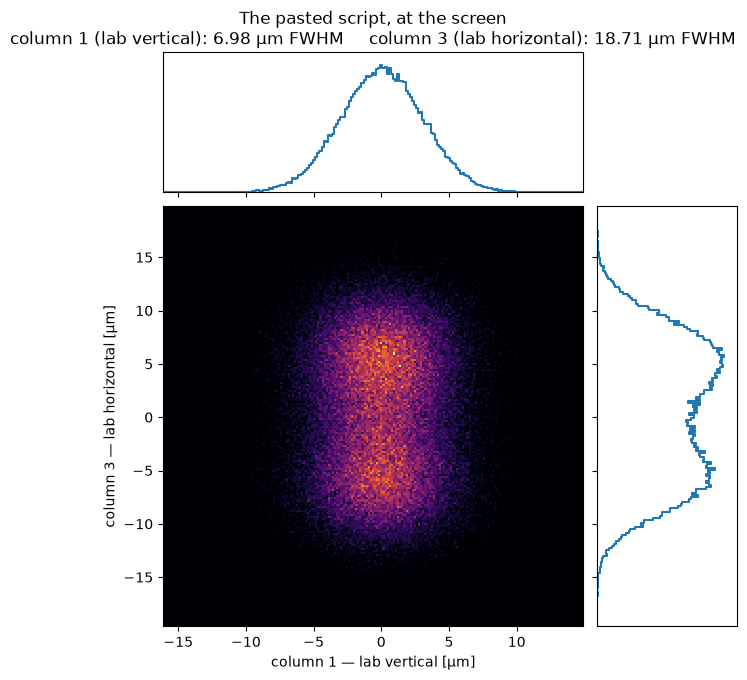

column 1: 3.09 µm rms   vertical source through the grating: 3.08 µm
column 3: 6.23 µm rms   horizontal source through an ideal ellipse: 2.82 µm


In [5]:
sizes = spot(beam, title="The pasted script, at the screen")

r_m, r_prime_m = 24.301, 7.573                    # grating: source distance, image distance
alpha_rad, beta_rad = 1.548912027, 1.536274133    # grating angles, from the export
p_m, q_m = 26.301, 5.573                          # elliptical mirror
sigma_h_m, sigma_v_m = 1.65e-5, 1.84e-5           # source rms size

col1_expected_m = sigma_v_m * r_prime_m * np.cos(alpha_rad) / (r_m * np.cos(beta_rad))   # Part 2
col3_ideal_m = sigma_h_m * q_m / p_m                                                     # Part 1

print(f"column 1: {sizes['rms_1_m'] * 1e6:.2f} µm rms   vertical source through the grating: {col1_expected_m * 1e6:.2f} µm")
print(f"column 3: {sizes['rms_3_m'] * 1e6:.2f} µm rms   horizontal source through an ideal ellipse: {col3_ideal_m * 1e6:.2f} µm")

assert np.isclose(sizes["rms_1_m"], col1_expected_m, rtol=0.01)   # the mirror leaves column 1 alone
assert sizes["rms_3_m"] > 1.4 * col3_ideal_m                      # and column 3 is well short of ideal

Column 1 is Part 2's number: a horizontally deflecting mirror does not touch the dispersive direction. Column 3 is nearly twice what an ideal ellipse delivers.

## 3. Component Breakdown

The same script, one block per cell. Each optic gets its own name, so all three stay around to inspect. Section 3.3 checks the rebuilt beam against the pasted one.

In [6]:
beam_paste = beam.duplicate()   # keep the pasted script's result for the comparison in 3.3

### 3.1 Source and monochromator

Part 2's cells, unchanged: the source, the plane mirror, the grating, and the check that the export's angles and distances solve the grating equation and the focus condition at 1000 eV. Part 2, Section 3, explains each argument.

In [7]:
light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
light_source.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
light_source.set_depth_distribution_off()
light_source.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
light_source.set_energy_distribution_singleline(1000, unit='eV')
light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
beam = light_source.get_beam()

In [8]:
from syned.beamline.shape import Rectangle
from syned.beamline.element_coordinates import ElementCoordinates
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGrating

mirror = S4PlaneMirror(name='Plane Mirror V',
    boundary_shape=Rectangle(x_left=-0.008, x_right=0.008, y_bottom=-0.155, y_top=0.155),
    f_reflec=0,
    f_refl=0, file_refl='<none>', refraction_index=0.99999+0.001j,
    coating_material='Si', coating_density=2.33, coating_roughness=0,
    dabax=None,
    )
mirror_coordinates = ElementCoordinates(p=24.123903, q=0.0886895, angle_radial=1.54259308, angle_azimuthal=0, angle_radial_out=1.54259308)

grating = S4PlaneGrating(name='VLS Grating (y = 24.301 m, p = 24.301 m, q = 7.573 m)',
    boundary_shape=None, f_ruling=1, order=-1,
    ruling=287440.0, ruling_coeff_linear=142771.836,
    ruling_coeff_quadratic=24131.408, ruling_coeff_cubic=4470.25,
    ruling_coeff_quartic=0.0,
    )
grating_coordinates = ElementCoordinates(p=0.0886895, q=7.573, angle_radial=1.548912027, angle_azimuthal=3.141592654, angle_radial_out=1.536274133)

In [9]:
hc_eVm = 1.239841984e-6                      # h·c [eV·m]
g0_per_m, g1_per_m2 = 287440.0, 142771.836   # ruling [l/m], [l/m²]
r_m, r_prime_m, dy_m = 24.301, 7.573, 0.010

alpha_rad, beta_rad = grating_coordinates.angle_radial(), grating_coordinates.angle_radial_out()
wavelength_m = hc_eVm / 1000.0
D_rad = np.pi - alpha_rad - beta_rad
L_MG_m = dy_m / np.sin(D_rad)
d_SM_m = r_m - dy_m / np.tan(D_rad)

assert np.isclose(np.sin(alpha_rad) - np.sin(beta_rad), wavelength_m * g0_per_m, rtol=1e-6)
assert np.isclose(np.cos(alpha_rad)**2 / r_m + np.cos(beta_rad)**2 / r_prime_m, wavelength_m * g1_per_m2, rtol=1e-5)
assert np.isclose(mirror_coordinates.angle_radial(), (alpha_rad + beta_rad) / 2, atol=1e-9)
assert np.isclose(d_SM_m, mirror_coordinates.p(), atol=1e-6)
assert np.isclose(L_MG_m, mirror_coordinates.q() + grating_coordinates.p(), atol=1e-6)
print("The export's monochromator is Part 2's: grating equation, focus condition and layout all hold at 1000 eV.")

The export's monochromator is Part 2's: grating equation, focus condition and layout all hold at 1000 eV.


### 3.2 Refocusing mirror

Three objects, in the export's order:

- **`ideal_mirror`** — Part 1's elliptical cylinder: same `p_focus`, `q_focus` and grazing angle. Its aperture is 20 mm wide and runs from −125.8 to +126.0 mm along the mirror, which is exactly the span of the measurement (3.4).
- **`numerical_mesh_mirror`** — reads the height map from the file. Its aperture and reflectivity arguments are placeholders: the combined optic takes both from the ideal mirror.
- **`measured_mirror`** — the sum: the ideal ellipse plus the measured deviations. This is the optic that gets traced.

In [10]:
from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror
from shadow4.beamline.optical_elements.mirrors.s4_numerical_mesh_mirror import S4NumericalMeshMirror
from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirror

surface_file = "data/shadow4_COSMIC-U_M3_AXO_DLTP_Resid_4thOrderRemoved_IntResidHeight.h5"

ideal_mirror = S4EllipsoidMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)',
    boundary_shape=Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.1258, y_top=0.126),
    surface_calculation=0,
    min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
    p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156,
    is_cylinder=1, cylinder_direction=0, convexity=1,
    f_reflec=0,
    f_refl=0, file_refl='<none>', refraction_index=0.99999+0.001j,
    coating_material='Si', coating_density=2.33, coating_roughness=0,
    dabax=None,
    )

numerical_mesh_mirror = S4NumericalMeshMirror(name='Numerical Mesh Mirror', boundary_shape=None,
    xx=None, yy=None, zz=None, surface_data_file=surface_file,
    f_reflec=0,
    f_refl=0, file_refl='', refraction_index=1,
    coating_material='', coating_density=1, coating_roughness=0,
    dabax=None,
    )

measured_mirror = S4AdditionalNumericalMeshMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)',
                                                  ideal_mirror=ideal_mirror,
                                                  numerical_mesh_mirror=numerical_mesh_mirror)

assert measured_mirror.get_boundary_shape() is ideal_mirror.get_boundary_shape()   # the aperture is the ideal mirror's

**Placement.** Azimuth π/2, 1.25° grazing, `p` = −5.573 m back from the screen plane (Section 1). The ellipse's `p_focus`, 26.301 m, has to be the distance the beam actually travels from the source to the mirror — through the monochromator, which lengthens the path slightly.

In [11]:
ellipse_coordinates = ElementCoordinates(p=-5.573, q=5.573, angle_radial=1.548979711, angle_azimuthal=1.570796327, angle_radial_out=1.548979711)

# source -> plane mirror -> grating -> screen plane, then back to the mirror
path_m = (mirror_coordinates.p() + mirror_coordinates.q() + grating_coordinates.p()
          + grating_coordinates.q() + ellipse_coordinates.p())
print(f"source to elliptical mirror along the beam: {path_m:.4f} m   (p_focus = 26.301 m)")

assert np.isclose(path_m, 26.301, atol=1e-3)                      # the ellipse's first focus is the source
assert np.isclose(ellipse_coordinates.q(), 5.573)                  # and its second is on the screen

source to elliptical mirror along the beam: 26.3013 m   (p_focus = 26.301 m)


### 3.3 Elements, trace, record

As in Parts 1 and 2: each optic, its placement and the beam arriving at it become an `...Element`, and `trace_beam()` returns the beam leaving it. The combined mirror has its own element class, `S4AdditionalNumericalMeshMirrorElement`.

In [12]:
from shadow4.beamline.s4_beamline import S4Beamline
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
from shadow4.beamline.optical_elements.gratings.s4_plane_grating import S4PlaneGratingElement
from shadow4.beamline.optical_elements.mirrors.s4_additional_numerical_mesh_mirror import S4AdditionalNumericalMeshMirrorElement

beamline = S4Beamline()
beamline.set_light_source(light_source)

mirror_element = S4PlaneMirrorElement(optical_element=mirror, coordinates=mirror_coordinates,
                                      movements=None, input_beam=beam)
beam, mirror_footprint = mirror_element.trace_beam()
beamline.append_beamline_element(mirror_element)

grating_element = S4PlaneGratingElement(optical_element=grating, coordinates=grating_coordinates,
                                        movements=None, input_beam=beam)
beam, grating_footprint = grating_element.trace_beam()
beamline.append_beamline_element(grating_element)

ellipse_element = S4AdditionalNumericalMeshMirrorElement(optical_element=measured_mirror, coordinates=ellipse_coordinates,
                                                         movements=None, input_beam=beam)
beam, ellipse_footprint = ellipse_element.trace_beam()
beamline.append_beamline_element(ellipse_element)

print(beamline.distances_summary())

  ********  SUMMARY OF DISTANCES ********
   ** DISTANCES FOR ALL O.E. [m] **           
          OE         TYPE           p[m]           q[m]         src-oe     src-screen 
           1       MIRROR        24.1239         0.0887        24.1239        24.2126 
           2      GRATING         0.0887         7.5730        24.3013        31.8743 
           3       MIRROR        -5.5730         5.5730        26.3013        31.8743 

   ** FOCUSING ELEMENTS **           
        OE                SHAPE      p_foc      q_foc        1/M 
         1                Plane          ?          ?          ? 
         3        NumericalMesh          ?          ?          ? 

Sum of Alphas [deg]:         270.000 
Sum of Alphas Mod 180 [deg]: 90.000 
Sum of Alphas Mod 360 [deg]: 270.000 

Total deflection angle H =    -0.043633 rad =    -2.500 deg
Total deflection angle V =     0.000000 rad =     0.000 deg 



In [13]:
beam.retrace(0.0)   # same as # main

assert np.array_equal(beam.rays, beam_paste.rays)
print("Rebuilt beam is identical to the pasted script's, ray for ray.")

Rebuilt beam is identical to the pasted script's, ray for ray.


### 3.4 The height map

## 4. Ideal vs. Measured, and the Exit Slit